# INTEGRANTES
* Daniel Mateo Quito Rueda
* Natalia Rico Torres
* Jose Manuel Pinzon Mendivelso

In [2]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
pd.set_option('display.max_columns', None)

student_performance = fetch_ucirepo(id=320) 
student_performance.keys()
warnings.filterwarnings('ignore')

In [3]:
print(student_performance.metadata.additional_info.variable_info)

# Attributes for both student-mat.csv (Math course) and student-por.csv (Portuguese language course) datasets:
1 school - student's school (binary: 'GP' - Gabriel Pereira or 'MS' - Mousinho da Silveira)
2 sex - student's sex (binary: 'F' - female or 'M' - male)
3 age - student's age (numeric: from 15 to 22)
4 address - student's home address type (binary: 'U' - urban or 'R' - rural)
5 famsize - family size (binary: 'LE3' - less or equal to 3 or 'GT3' - greater than 3)
6 Pstatus - parent's cohabitation status (binary: 'T' - living together or 'A' - apart)
7 Medu - mother's education (numeric: 0 - none,  1 - primary education (4th grade), 2 â€“ 5th to 9th grade, 3 â€“ secondary education or 4 â€“ higher education)
8 Fedu - father's education (numeric: 0 - none,  1 - primary education (4th grade), 2 â€“ 5th to 9th grade, 3 â€“ secondary education or 4 â€“ higher education)
9 Mjob - mother's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), '

In [4]:
student_performance.data.keys()

dict_keys(['ids', 'features', 'targets', 'original', 'headers'])

In [5]:
df=student_performance.data.original
df['Final']=df['G1']+df['G2']+df['G3']
df['Aprueba']=np.where(df['Final']>=40,'1','0')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Final,Aprueba
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11,22,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11,31,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12,37,0
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14,42,1
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13,37,0


In [6]:
df2 = pd.melt(df, 
               id_vars=df.columns.difference(['G1', 'G2', 'G3', 'Final']),
               value_vars=['G1', 'G2', 'G3'],
               var_name='Examen',
               value_name='Calificacion')
df2.head()

,Aprueba,Dalc,Fedu,Fjob,Medu,Mjob,Pstatus,Walc,absences,activities,address,age,failures,famrel,famsize,famsup,freetime,goout,guardian,health,higher,internet,nursery,paid,reason,romantic,school,schoolsup,sex,studytime,traveltime,Examen,Calificacion
0,0,1,4,teacher,4,at_home,A,1,4,no,U,18,0,4,GT3,no,3,4,mother,3,yes,no,yes,no,course,no,GP,yes,F,2,2,G1,0
1,0,1,1,other,1,at_home,T,1,2,no,U,17,0,5,GT3,yes,3,3,father,3,yes,yes,no,no,course,no,GP,no,F,2,1,G1,9
2,0,2,1,other,1,at_home,T,3,6,no,U,15,0,4,LE3,no,3,2,mother,3,yes,yes,yes,no,other,no,GP,yes,F,2,1,G1,12
3,1,1,2,services,4,health,T,1,0,yes,U,15,0,3,GT3,yes,2,2,mother,5,yes,yes,yes,no,home,yes,GP,no,F,3,1,G1,14
4,0,1,3,other,3,other,T,2,0,no,U,16,0,4,GT3,yes,3,2,father,5,yes,no,yes,no,home,no,GP,no,F,2,1,G1,11


Se analizaron las variables categóricas y se decidió excluir las columnas ['famsize', 'reason', 'nursey', 'Fjob', 'Mjob', 'Pstatus', 'schoolsup', 'famsup', 'Final', 'Aprueba', 'activities', 'romantic'] dado que no se considera que tengan relación o sean relevantes al momento de estimar las notas G1, G2 y G3. <br><br>

A continuación se muestran algunos análisis que se realizaron sobre variables en donde se trata de identificar si hay algún patrón dentro de las variables que permita identificar si se tiene alguna influencia significativa sobre las variables en estudio.

In [8]:
df2.groupby(['address','Examen'])['Calificacion'].describe()

count       mean       std  min   25%   50%   75%   max
address Examen                                                         
R       G1      197.0  10.746193  2.724894  4.0   9.0  10.0  13.0  18.0
        G2      197.0  10.888325  3.101632  0.0   9.0  11.0  13.0  19.0
        G3      197.0  11.086294  3.605221  0.0  10.0  11.0  13.0  19.0
U       G1      452.0  11.683628  2.708187  0.0  10.0  12.0  14.0  19.0
        G2      452.0  11.867257  2.779413  0.0  10.0  12.0  14.0  18.0
        G3      452.0  12.263274  2.987658  0.0  10.0  12.0  14.0  19.0

<Axes: xlabel='address', ylabel='Calificacion'>

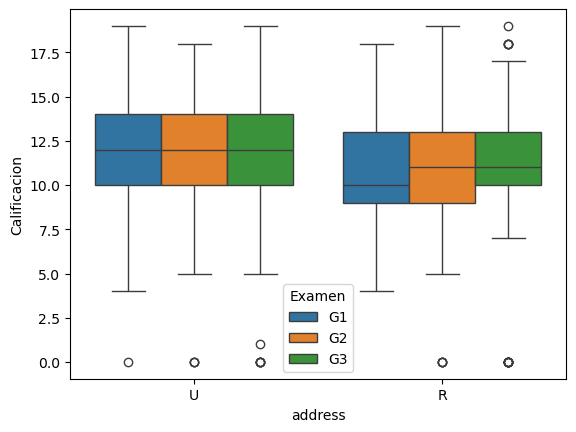

In [9]:
sns.boxplot(df2, x="address", y="Calificacion",hue='Examen')

In [10]:
df2.groupby(['sex','Examen'])['Calificacion'].describe()

count       mean       std  min   25%   50%   75%   max
sex Examen                                                         
F   G1      383.0  11.637076  2.794232  0.0  10.0  12.0  14.0  19.0
    G2      383.0  11.822454  2.967506  0.0  10.0  12.0  14.0  19.0
    G3      383.0  12.253264  3.124147  0.0  10.0  12.0  14.0  19.0
M   G1      266.0  11.056391  2.640865  4.0   9.0  11.0  13.0  18.0
    G2      266.0  11.206767  2.800019  0.0   9.0  11.0  13.0  18.0
    G3      266.0  11.406015  3.320690  0.0  10.0  11.0  13.0  19.0

<Axes: xlabel='sex', ylabel='Calificacion'>

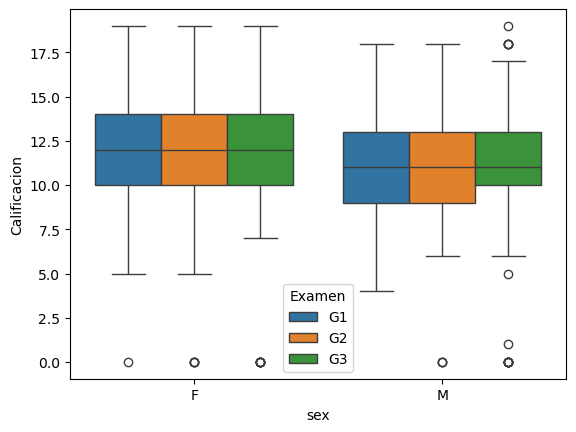

In [11]:
sns.boxplot(df2, x="sex", y="Calificacion",hue='Examen')

In [12]:
df2.groupby(['famsize','Examen'])['Calificacion'].describe()

count       mean       std  min   25%   50%   75%   max
famsize Examen                                                         
GT3     G1      457.0  11.315098  2.761986  0.0   9.0  11.0  13.0  18.0
        G2      457.0  11.496718  2.982495  0.0  10.0  11.0  13.0  18.0
        G3      457.0  11.811816  3.351426  0.0  10.0  12.0  14.0  19.0
LE3     G1      192.0  11.598958  2.701677  5.0  10.0  11.0  14.0  19.0
        G2      192.0  11.744792  2.742429  0.0  10.0  11.0  14.0  19.0
        G3      192.0  12.130208  2.919285  0.0  10.0  12.0  14.0  19.0

<Axes: xlabel='famsize', ylabel='Calificacion'>

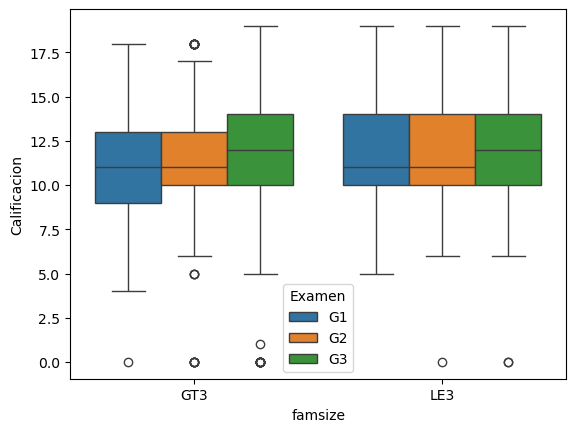

In [13]:
sns.boxplot(df2, x="famsize", y="Calificacion",hue='Examen')

In [14]:
df2.groupby(['Pstatus','Examen'])['Calificacion'].describe()

count       mean       std  min   25%   50%    75%   max
Pstatus Examen                                                          
A       G1       80.0  11.287500  2.960473  0.0  10.0  11.5  13.00  17.0
        G2       80.0  11.425000  3.228728  0.0  10.0  11.5  13.25  18.0
        G3       80.0  11.912500  3.222523  0.0  10.0  12.0  14.00  18.0
T       G1      569.0  11.414763  2.716057  4.0  10.0  11.0  13.00  19.0
        G2      569.0  11.590510  2.869089  0.0  10.0  11.0  13.00  19.0
        G3      569.0  11.905097  3.234626  0.0  10.0  12.0  14.00  19.0

<Axes: xlabel='Pstatus', ylabel='Calificacion'>

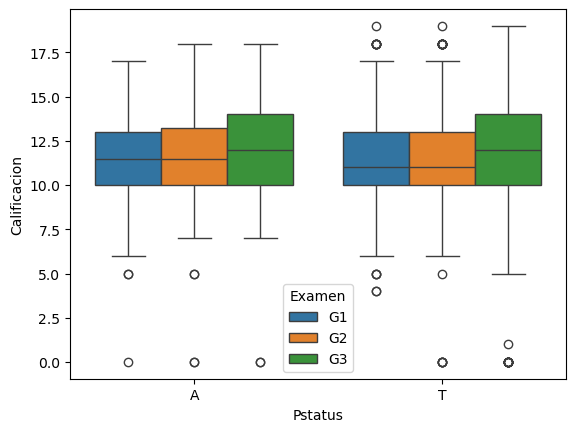

In [15]:
sns.boxplot(df2, x="Pstatus", y="Calificacion",hue='Examen')

In [16]:
df2.groupby(['Medu','Examen'])['Calificacion'].describe()

count       mean       std   min    25%   50%    75%   max
Medu Examen                                                            
0    G1        6.0  10.833333  1.940790   9.0   9.25  10.5  11.75  14.0
     G2        6.0  11.166667  1.722401   9.0  10.25  11.0  11.75  14.0
     G3        6.0  11.666667  1.751190  10.0  11.00  11.0  11.75  15.0
1    G1      143.0  10.398601  2.597778   5.0   9.00  10.0  12.00  19.0
     G2      143.0  10.524476  2.777759   0.0   9.00  10.0  12.00  17.0
     G3      143.0  10.797203  3.163523   0.0   9.00  11.0  13.00  18.0
2    G1      186.0  11.204301  2.364417   6.0   9.25  11.0  13.00  18.0
     G2      186.0  11.284946  2.770401   0.0  10.00  11.0  13.00  18.0
     G3      186.0  11.661290  3.061232   0.0  10.00  12.0  13.00  18.0
3    G1      139.0  11.323741  2.782491   4.0  10.00  11.0  13.00  18.0
     G2      139.0  11.561151  2.968714   0.0  10.00  11.0  13.00  19.0
     G3      139.0  11.920863  3.123229   0.0  10.00  12.0  14.00  19.0
4    G1      175.0  12.502857  2.874530   0.0  11.00  13.0  14.00  18.0
     G2      175.0  12.748571  2.773994   0.0  11.00  13.0  15.00  18.0
     G3      175.0  13.068571  3.236978   0.0  11.00  13.0  15.00  19.0

<Axes: xlabel='Medu', ylabel='Calificacion'>

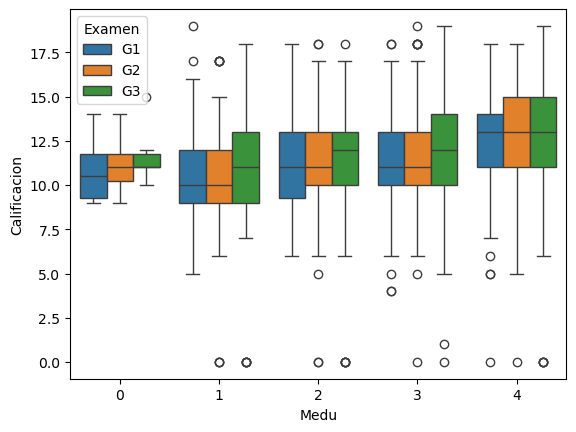

In [17]:
sns.boxplot(df2, x="Medu", y="Calificacion",hue='Examen')

In [18]:
df2.groupby(['guardian','Examen'])['Calificacion'].describe()

count       mean       std  min   25%   50%   75%   max
guardian Examen                                                         
father   G1      153.0  11.784314  2.608037  5.0  10.0  12.0  14.0  19.0
         G2      153.0  11.875817  2.791718  0.0  10.0  12.0  13.0  18.0
         G3      153.0  12.202614  3.192012  0.0  11.0  12.0  14.0  19.0
mother   G1      455.0  11.389011  2.806594  0.0  10.0  11.0  13.0  18.0
         G2      455.0  11.573626  2.950130  0.0  10.0  11.0  13.0  19.0
         G3      455.0  11.896703  3.279943  0.0  10.0  12.0  14.0  19.0
other    G1       41.0  10.073171  2.114122  7.0   9.0  10.0  12.0  14.0
         G2       41.0  10.390244  2.709964  0.0   9.0  10.0  12.0  15.0
         G3       41.0  10.902439  2.624927  0.0  10.0  11.0  12.0  15.0

<Axes: xlabel='guardian', ylabel='Calificacion'>

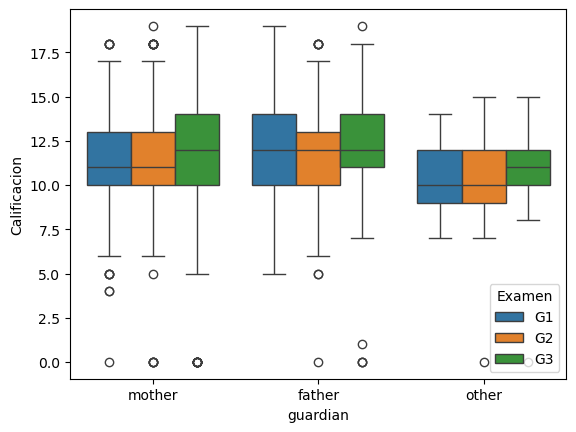

In [19]:
sns.boxplot(df2, x="guardian", y="Calificacion",hue='Examen')

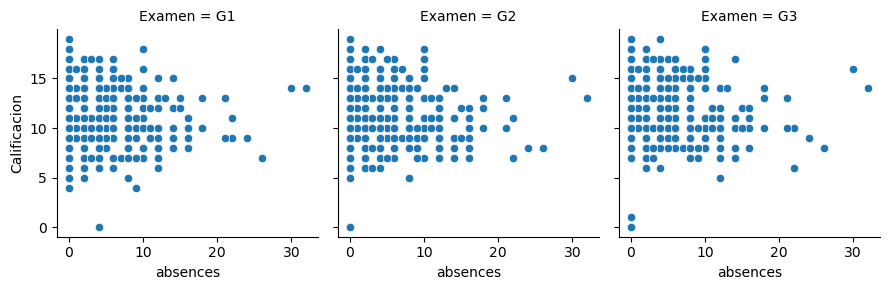

In [20]:
# sns.scatterplot(df2, x="absences", y="Calificacion", hue="Examen")
g = sns.FacetGrid(df2, col="Examen")
g.map(sns.scatterplot, "absences", "Calificacion")

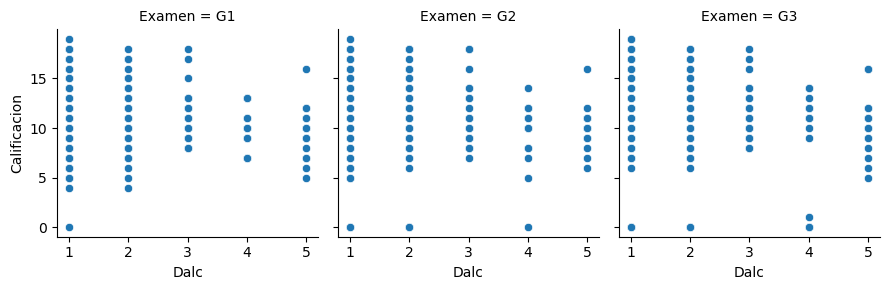

In [21]:
g = sns.FacetGrid(df2, col="Examen")
g.map(sns.scatterplot, "Dalc", "Calificacion")

Rural - G3 - Disminucion (Menos datos)
Male - G3 - Disminucion (Menos datos)
Medu - Si hay cambios en las notas según la variable Medu, Pedu, a medida que incrementa la educacion de los padres incrementa tambien la nota
Guardian - Disminucion de notas cuando el niñero es "otro"

En las variables numericas:
Dalc - A medida que aumenta el consumo también disminuye la calificación obtenida por el estudiante en el examen.

En primer lugar se limpia el dataframe excluyendo los campos que se consideraron no relevantes o sin relación con la variable de estudio, posteriomente se determinan cuales son las variables categóricas y numéricas, con el fin de poder realizar la coficiación a variable dummy de las variables categóricas 

In [24]:
No_Relevantes=['famsize','reason','nursey','Fjob','Mjob','Pstatus','schoolsup','famsup','activities','romantic','G1','G2','G3','Final','Aprueba']
df_limpio=df[df.columns.difference(No_Relevantes)]

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

Numericas=['age','traveltime','studytime','failures','famrel','freetime','goout','Dalc','Walc','health','absences']
df_Numericas=df_limpio[Numericas]
df_Categoricas = df_limpio[df_limpio.columns.difference(Numericas)]
Categoricas = df_Categoricas.columns

Creación del dataframe teniendo en cuenta las variables numéricas originales y variables categóricas convertidas en variables dummy utilizando OneHotEncoder

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), Categoricas)
    ], remainder='passthrough')

In [28]:
df_dummys = preprocessor.fit_transform(df_limpio)
df_dummys = pd.DataFrame(df_dummys, columns=preprocessor.get_feature_names_out())

## MODELO REGRESION LINEAL G1 

Una vez se tiene el dataframe listo para realizar el modelo se procede a establecer los índices de correlación entre las variables independientes y la variable dependiente (En este caso sería G1)

In [31]:
df_dummys['G1'] = df['G1']
Matriz_Correlacion = df_dummys.corr()
Matriz_Correlacion['G1'].sort_values(ascending=False).head()

G1                      1.000000
cat__higher_yes         0.349030
cat__school_GP          0.292626
remainder__studytime    0.260875
cat__Medu_4             0.244491
Name: G1, dtype: float64

Se determinan las variables que tienen una correlación leve (Ya sea negativa o positiva), para ello se filtran solo las variables que tienen un índice de correlación mayor al 0.1.

In [33]:
Correlacion_G1=Matriz_Correlacion['G1'].reset_index()
Correlacion_G1=Correlacion_G1[Correlacion_G1['G1'].abs()>0.1].sort_values(['index','G1'])

Variables_G1 = Correlacion_G1['index'].tolist()
X = df_dummys[Variables_G1].drop('G1', axis=1)
Y = df_dummys['G1']

Procedemos a crear la primera versión del modelo de regresión lineal múltiple, con todas las variables que tienen una correlación leve.

In [35]:
# Dividir los datos en conjuntos de entrenamiento y prueba
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=50)

# Crear y entrenar el modelo de regresión lineal múltiple
modelo1 = sm.OLS(y_train, X_train)
# Ajustar el modelo
resultado = modelo1.fit()

# Imprimir el resumen del modelo
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:                     G1   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     10.42
Date:                Thu, 10 Oct 2024   Prob (F-statistic):           7.09e-23
Time:                        21:55:15   Log-Likelihood:                -876.02
No. Observations:                 389   AIC:                             1788.
Df Residuals:                     371   BIC:                             1859.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
cat__Fedu_1              -0.55

Una vez obtenido el modelo de regresión, se limpian las variables que no cumplan con la significancia del 0.05, adicionalmente, para no generar problemas de multicolinearidad, se limpiarán las variables dummy, dejando solo una de las categorías y tomando como escenario base la categoría dummy eliminada.
Al realizar esta limpieza se observa que algunas de las variables resultan ser NO significativas, por lo cual se eliminan también del modelo, dejando solo las variables con un p valor inferior a 0.05. De tal manera que el modelo queda: <br><br>
G1 = B0+ B1* cat__Fedu_1 + B2* cat__school_MS + B3* remainder__Dalc + B4* remainder__absences + B5*remainder__failures + B6* remainder__studytime

In [37]:
X = df_dummys[['cat__Fedu_1',  
                 'cat__school_MS', 
                'remainder__Dalc', 'remainder__absences',
                'remainder__failures', 'remainder__studytime']]
Y = df_dummys['G1']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=50)

X_train_const = sm.add_constant(X_train)

modelo1 = sm.OLS(y_train, X_train_const)

resultado = modelo1.fit()

print(resultado.summary())

# ,'cat__address_R','cat__higher_no','cat__internet_no','cat__school_GP','cat__sex_M','cat__higher_yes', 'cat__sex_F',cat__address_U,cat__internet_yes

                            OLS Regression Results                            
Dep. Variable:                     G1   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     25.02
Date:                Thu, 10 Oct 2024   Prob (F-statistic):           4.89e-25
Time:                        21:55:15   Log-Likelihood:                -887.49
No. Observations:                 389   AIC:                             1789.
Df Residuals:                     382   BIC:                             1817.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   12.4497 

**ANALISIS RESULTADOS**

### CAPACIDAD PREDICTIVA

In [40]:
from sklearn.metrics import mean_squared_error

X_test_const = sm.add_constant(X_test)

predicciones = resultado.predict(exog = X_test_const)

rmse = mean_squared_error(
        y_true  = y_test,
        y_pred  = predicciones,
        squared = False
       )

print(f"El error (rmse) de test es: {rmse}")


El error (rmse) de test es: 2.290239101664483


A pesar de que el modelo solo cuenta con un R2 de 27, el error (rmse) de test es 2.29 lo cual nos indique que las predicciones del modelo final se alejan en promedio 2.29 unidades del valor real, lo cual representa un buen ajuste sobre la predicción.



In [42]:
from sklearn.metrics import r2_score
Y_pred_train=resultado.predict(X_train_const) ### Entrenamiento
Y_pred_test=resultado.predict(X_test_const) ## Prueba
print("R2 train",np.round(r2_score(y_train, Y_pred_train),2)*100, "%")
print("R2 prueba",np.round(r2_score(y_test, Y_pred_test),2)*100, "%")

R2 train 28.000000000000004 %
R2 prueba 26.0 %


Se observa que tanto el R2 del modelo train y el R2 del test indican que las variables independientes pueden explicar el comportamiento de la variable dependiente entre un 26% y un 28%, esta cercanía en los datos nos ayuda a determinar que el modelo no está sobreajustado y mantiene su rango de predicción con valores nuevos. 

In [44]:
from sklearn.metrics import mean_squared_error
Y_pred_train=resultado.predict(X_train_const) ### Entrenamiento
Y_pred_test=resultado.predict(X_test_const) ## Prueba
print("MSE train",np.round(mean_squared_error(y_train, Y_pred_train),2))
print("MSE prueba",np.round(mean_squared_error(y_test, Y_pred_test),2))

MSE train 5.61
MSE prueba 5.25


Este valor indica que en promedio, el cuadrado de la diferencia entre los valores predichos por el modelo y los valores reales en el conjunto de entrenamiento es de 5.61. En esta métrica encontramos un poco más de variabilidad entre los valores proyectados y los reales.

## MODELO REGRESION LINEAL G2

In [47]:
df_dummys['G2'] = df['G2']
Matriz_Correlacion = df_dummys.corr()
Matriz_Correlacion['G2'].sort_values(ascending=False).head()

G2                 1.000000
G1                 0.864982
cat__higher_yes    0.331953
cat__school_GP     0.269776
cat__Medu_4        0.245949
Name: G2, dtype: float64

In [48]:
Correlacion_G2=Matriz_Correlacion['G2'].reset_index()
Correlacion_G2=Correlacion_G2[Correlacion_G2['G2'].abs()>0.1].sort_values(['index','G2'])

Variables_G2 = Correlacion_G2['index'].tolist()
X = df_dummys[Variables_G2].drop(['G1','G2'], axis=1)
Y = df_dummys['G2']

In [49]:
# Dividir los datos en conjuntos de entrenamiento y prueba
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=42)

# Crear y entrenar el modelo de regresión lineal múltiple
modelo1 = sm.OLS(y_train, X_train)
# Ajustar el modelo
resultado = modelo1.fit()

# Imprimir el resumen del modelo
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:                     G2   R-squared:                       0.337
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     10.47
Date:                Thu, 10 Oct 2024   Prob (F-statistic):           6.50e-24
Time:                        21:55:16   Log-Likelihood:                -877.97
No. Observations:                 389   AIC:                             1794.
Df Residuals:                     370   BIC:                             1869.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
cat__Fedu_1              -0.42

Se limpian las variables que no cumplan con la significancia del 0.05, adicionalmente, para no generar problemas de multicolinearidad, se limpiarán las variables dummy, dejando solo una de las categorías y tomando como escenario base la variable eliminada

Luego de haber limpiado el modelo anterior y de haber dejado solo las variables significativas y los escenarios base para no generar problemas de multicolinearidad, se determina que la ecuación de la regresión queda de la siguiente manera: <br><br>
G2 = B0+ B1* cat__higher_yes + B2* cat__school_MS + B3* remainder__Dalc + B4* remainder__absences + B5*remainder__failures + B6* remainder__studytime

In [52]:
X = df_dummys[[
'cat__higher_yes',
'cat__school_MS',
'remainder__Dalc',
'remainder__absences',
'remainder__failures',
'remainder__studytime',
]]
Y = df_dummys['G2']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=42)

X_train_const = sm.add_constant(X_train)

modelo1 = sm.OLS(y_train, X_train_const)

resultado = modelo1.fit()

print(resultado.summary())

# 'cat__address_R','cat__higher_no','cat__internet_no','cat__school_GP','cat__sex_M','cat__higher_yes', 'cat__sex_F',cat__address_U,cat__internet_yes

                            OLS Regression Results                            
Dep. Variable:                     G2   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     29.96
Date:                Thu, 10 Oct 2024   Prob (F-statistic):           1.99e-29
Time:                        21:55:16   Log-Likelihood:                -883.01
No. Observations:                 389   AIC:                             1780.
Df Residuals:                     382   BIC:                             1808.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   10.9927 

### CAPACIDAD PREDICTIVA

In [54]:
from sklearn.metrics import mean_squared_error
X_test_const = sm.add_constant(X_test)

predicciones = resultado.predict(exog = X_test_const)

rmse = mean_squared_error(
        y_true  = y_test,
        y_pred  = predicciones,
        squared = False
       )

print(f"El error (rmse) de test es: {rmse}")


El error (rmse) de test es: 2.684553343099634


A pesar de que el modelo solo cuenta con un R2 de 30, el error (rmse) de test es 3.44 lo cual nos indique que las predicciones del modelo final se alejan en promedio 3.44 unidades del valor real, lo cual representa un buen ajuste sobre la predicción. A pesar de que este modelo tiene una bondad de ajuste mayor al anterior, vemos que los errores son más ámplios.



In [56]:
from sklearn.metrics import r2_score
Y_pred_train=resultado.predict(X_train_const) ### Entrenamiento
Y_pred_test=resultado.predict(X_test_const) ## Prueba
print("R2 train",np.round(r2_score(y_train, Y_pred_train),2)*100, "%")
print("R2 prueba",np.round(r2_score(y_test, Y_pred_test),2)*100, "%")

R2 train 32.0 %
R2 prueba 20.0 %


In [57]:
from sklearn.metrics import mean_squared_error
Y_pred_train=resultado.predict(X_train_const) ### Entrenamiento
Y_pred_test=resultado.predict(X_test_const) ## Prueba
print("MSE train",np.round(mean_squared_error(y_train, Y_pred_train),2))
print("MSE prueba",np.round(mean_squared_error(y_test, Y_pred_test),2))

MSE train 5.49
MSE prueba 7.21


## MODELO REGRESION LINEAL G3

In [59]:
df_dummys['G3'] = df['G3']
Matriz_Correlacion = df_dummys.corr()
Matriz_Correlacion['G3'].sort_values(ascending=False).head()

G3                 1.000000
G2                 0.918548
G1                 0.826387
cat__higher_yes    0.332172
cat__school_GP     0.284294
Name: G3, dtype: float64

In [60]:
Correlacion_G3=Matriz_Correlacion['G3'].reset_index()
Correlacion_G3=Correlacion_G3[Correlacion_G3['G3'].abs()>0.1].sort_values(['index','G3'])

Variables_G3 = Correlacion_G3['index'].tolist()
X = df_dummys[Variables_G3].drop(['G1','G2','G3'], axis=1)
Y = df_dummys['G3']

In [61]:
# Dividir los datos en conjuntos de entrenamiento y prueba
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de regresión lineal múltiple
modelo1 = sm.OLS(y_train, X_train)
# Ajustar el modelo
resultado = modelo1.fit()

# Imprimir el resumen del modelo
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.328
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     15.33
Date:                Thu, 10 Oct 2024   Prob (F-statistic):           2.63e-34
Time:                        21:55:16   Log-Likelihood:                -1244.0
No. Observations:                 519   AIC:                             2522.
Df Residuals:                     502   BIC:                             2594.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
cat__Fedu_1              -0.68

In [62]:
X = df_dummys[[
'cat__higher_yes',
'cat__school_GP',
'remainder__failures',
'remainder__Dalc',
'remainder__studytime'
]]
Y = df_dummys['G2']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=42)

X_train_const = sm.add_constant(X_train)

modelo1 = sm.OLS(y_train, X_train_const)

resultado = modelo1.fit()

print(resultado.summary())

# 'cat__address_R','cat__higher_no','cat__internet_no','cat__school_GP','cat__sex_M','cat__higher_yes', 'cat__sex_F',cat__address_U,cat__internet_yes

                            OLS Regression Results                            
Dep. Variable:                     G2   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     35.47
Date:                Thu, 10 Oct 2024   Prob (F-statistic):           8.28e-30
Time:                        21:55:16   Log-Likelihood:                -884.01
No. Observations:                 389   AIC:                             1780.
Df Residuals:                     383   BIC:                             1804.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    9.4396 

### CAPACIDAD PREDICTIVA

In [64]:
from sklearn.metrics import mean_squared_error

X_test_const = sm.add_constant(X_test)

predicciones = resultado.predict(exog = X_test_const)

rmse = mean_squared_error(
        y_true  = y_test,
        y_pred  = predicciones,
        squared = False
       )

print(f"El error (rmse) de test es: {rmse}")


El error (rmse) de test es: 2.6951415015222944


In [65]:
from sklearn.metrics import r2_score
Y_pred_train=resultado.predict(X_train_const) ### Entrenamiento
Y_pred_test=resultado.predict(X_test_const) ## Prueba
print("R2 train",np.round(r2_score(y_train, Y_pred_train),2)*100, "%")
print("R2 prueba",np.round(r2_score(y_test, Y_pred_test),2)*100, "%")

R2 train 32.0 %
R2 prueba 20.0 %


In [66]:
from sklearn.metrics import mean_squared_error
Y_pred_train=resultado.predict(X_train_const) ### Entrenamiento
Y_pred_test=resultado.predict(X_test_const) ## Prueba
print("MSE train",np.round(mean_squared_error(y_train, Y_pred_train),2))
print("MSE prueba",np.round(mean_squared_error(y_test, Y_pred_test),2))

MSE train 5.51
MSE prueba 7.26


## REGRESION LOGISTICA

Para la creación del modelo de regresión logística para proyectar si un estudiante pasa o no la matería, se evaluará que impacto tienen las demás variables sobre este resultado.

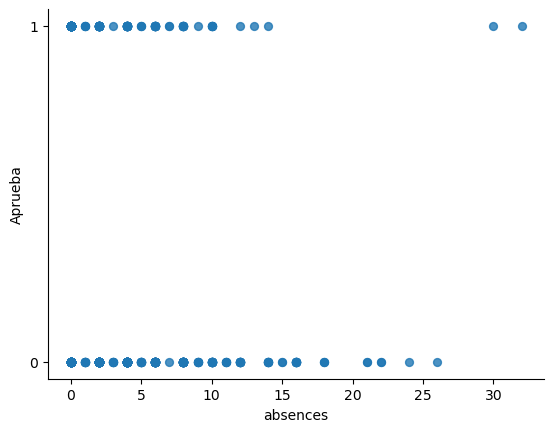

In [68]:
# Experiencia vs titulo_avanzado
df3 = df2[df2['Examen']=='G1']
from matplotlib import pyplot as plt
df3.plot(kind='scatter', x='absences', y='Aprueba', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [69]:
# Experiencia vs titulo_avanzado
df3[['Aprueba','Walc']].value_counts().reset_index().sort_values(['Walc','Aprueba'])

,Aprueba,Walc,count
0,0,1,166
3,1,1,81
1,0,2,102
5,1,2,48
2,0,3,88
7,1,3,32
4,0,4,75
8,1,4,12
6,0,5,38
9,1,5,7


Luego se eliminarán las variables que puedan no ser relevantes para la proyección de la variable "Aprueba"

In [70]:
No_Relevantes=['famsize','reason','nursey','Fjob','Mjob','Pstatus','schoolsup','famsup','activities','romantic','G1','G2','G3','Final']
df_limpio_logit=df[df.columns.difference(No_Relevantes)]

In [72]:
df_limpio_logit

,Aprueba,Dalc,Fedu,Medu,Walc,absences,address,age,failures,famrel,freetime,goout,guardian,health,higher,internet,nursery,paid,school,sex,studytime,traveltime
0,0,1,4,4,1,4,U,18,0,4,3,4,mother,3,yes,no,yes,no,GP,F,2,2
1,0,1,1,1,1,2,U,17,0,5,3,3,father,3,yes,yes,no,no,GP,F,2,1
2,0,2,1,1,3,6,U,15,0,4,3,2,mother,3,yes,yes,yes,no,GP,F,2,1
3,1,1,2,4,1,0,U,15,0,3,2,2,mother,5,yes,yes,yes,no,GP,F,3,1
4,0,1,3,3,2,0,U,16,0,4,3,2,father,5,yes,no,yes,no,GP,F,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,0,1,3,2,2,4,R,19,1,5,4,2,mother,5,yes,yes,no,no,MS,F,3,1
645,1,1,1,3,1,4,U,18,0,4,3,4,mother,1,yes,yes,yes,no,MS,F,2,1
646,0,1,1,1,1,6,U,18,0,1,1,1,mother,5,yes,no,yes,no,MS,F,2,2
647,0,3,1,3,4,6,U,17,0,2,4,5,mother,2,yes,yes,no,no,MS,M,1,2


In [73]:
## SE DEFINEN LAS VARIABLES NUMERICAS Y CATEGÓRICAS LAS CUALES SERÁN TRANSFORMADAS A CODIFICACIÓN DUMMY. 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
Numericas=['age','traveltime','studytime','failures','famrel','freetime','goout','Dalc','Walc','health','absences','Aprueba']#Aprueba no es numerica pero la coloco aquí para que la mantenga en el formato actual
df_Numericas=df_limpio_logit[Numericas]
df_Categoricas = df_limpio_logit[df_limpio_logit.columns.difference(Numericas)]
Categoricas = df_Categoricas.columns

In [74]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), Categoricas)
    ], remainder='passthrough')

In [75]:
df_dummys = preprocessor.fit_transform(df_limpio_logit)
df_dummys = pd.DataFrame(df_dummys, columns=preprocessor.get_feature_names_out())

In [105]:
# revision de los variables del dataframe.
df_dummys.columns

Index(['cat__Fedu_0', 'cat__Fedu_1', 'cat__Fedu_2', 'cat__Fedu_3',
       'cat__Fedu_4', 'cat__Medu_0', 'cat__Medu_1', 'cat__Medu_2',
       'cat__Medu_3', 'cat__Medu_4', 'cat__address_R', 'cat__address_U',
       'cat__guardian_father', 'cat__guardian_mother', 'cat__guardian_other',
       'cat__higher_no', 'cat__higher_yes', 'cat__internet_no',
       'cat__internet_yes', 'cat__nursery_no', 'cat__nursery_yes',
       'cat__paid_no', 'cat__paid_yes', 'cat__school_GP', 'cat__school_MS',
       'cat__sex_F', 'cat__sex_M', 'remainder__Aprueba', 'remainder__Dalc',
       'remainder__Walc', 'remainder__absences', 'remainder__age',
       'remainder__failures', 'remainder__famrel', 'remainder__freetime',
       'remainder__goout', 'remainder__health', 'remainder__studytime',
       'remainder__traveltime'],
      dtype='object')

Se revisan la correlación que pueden tener las variables independientes con la dependiente, para posteriormente filtrar las columnas que puedan tener un índice de correlación mayor o igual al 0.1, dado que podrían ser significativas en el modelo.

In [77]:
Matriz_Correlacion = df_dummys.corr()
Matriz_Correlacion['remainder__Aprueba'].sort_values(ascending=False).head()

remainder__Aprueba      1.000000
cat__Medu_4             0.236264
remainder__studytime    0.217917
cat__higher_yes         0.202513
cat__Fedu_4             0.160012
Name: remainder__Aprueba, dtype: float64

In [78]:
Correlacion_Logit=Matriz_Correlacion['remainder__Aprueba'].reset_index()
Correlacion_Logit=Correlacion_Logit[Correlacion_Logit['remainder__Aprueba'].abs()>0.1].sort_values(['index','remainder__Aprueba'])

In [107]:
Variables_Logit = Correlacion_Logit['index'].tolist()
Variables_Logit

['cat__Fedu_1',
 'cat__Fedu_4',
 'cat__Medu_1',
 'cat__Medu_2',
 'cat__Medu_4',
 'cat__address_R',
 'cat__address_U',
 'cat__higher_no',
 'cat__higher_yes',
 'cat__internet_no',
 'cat__internet_yes',
 'cat__school_GP',
 'cat__school_MS',
 'remainder__Aprueba',
 'remainder__Dalc',
 'remainder__Walc',
 'remainder__absences',
 'remainder__failures',
 'remainder__health',
 'remainder__studytime',
 'remainder__traveltime']

In [84]:
X = sm.add_constant(df_dummys[Variables_Logit].drop(['remainder__Aprueba'], axis=1)) # Matriz de variables independientes
X = X.astype(int)
df_dummys['remainder__Aprueba']=df_dummys['remainder__Aprueba'].astype(int)
modelo_logit = sm.Logit(df_dummys['remainder__Aprueba'], X).fit()

print(modelo_logit.summary())# Mostrar los resultados del modelo

Optimization terminated successfully.
         Current function value: 0.484446
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:     remainder__Aprueba   No. Observations:                  649
Model:                          Logit   Df Residuals:                      632
Method:                           MLE   Df Model:                           16
Date:                Thu, 10 Oct 2024   Pseudo R-squ.:                  0.1795
Time:                        21:57:26   Log-Likelihood:                -314.41
converged:                       True   LL-Null:                       -383.19
Covariance Type:            nonrobust   LLR p-value:                 2.151e-21
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.4416        nan        nan        nan         nan        

Inicialmente el modelo de regresión logística no obtuvo buenos resultados y se evidencia que la mayoría de las variables resultan ser no significativas para la proyección de los valores. Por lo cual se decide filtrar las variables que sean significativas con una significancia del 0.05.<br>
Dando resultado la siguiente ecuación:<br>
Aprueba = B0+ B1* remainder__studytime + B2* remainder__failures + B3* remainder__health + B4* remainder__Dalc

In [86]:
X = sm.add_constant(df_dummys[['remainder__studytime',
'remainder__failures',
'remainder__health',
'remainder__Dalc']]) # Matriz de variables independientes
X = X.astype(int)
df_dummys['remainder__Aprueba']=df_dummys['remainder__Aprueba'].astype(int)
modelo_logit = sm.Logit(df_dummys['remainder__Aprueba'], X).fit()
print(modelo_logit.summary())# Mostrar los resultados del modelo

Optimization terminated successfully.
         Current function value: 0.521896
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:     remainder__Aprueba   No. Observations:                  649
Model:                          Logit   Df Residuals:                      644
Method:                           MLE   Df Model:                            4
Date:                Thu, 10 Oct 2024   Pseudo R-squ.:                  0.1161
Time:                        21:57:28   Log-Likelihood:                -338.71
converged:                       True   LL-Null:                       -383.19
Covariance Type:            nonrobust   LLR p-value:                 2.190e-18
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.6672      0.386     -1.729      0.084      -1.423       0.089

In [111]:
data=df_dummys[['remainder__studytime',
'remainder__failures',
'remainder__health',
'remainder__Dalc','remainder__Aprueba']]
data['prediccion_prob'] = modelo_logit.predict(X)
data['prediccion'] = (data['prediccion_prob'] >= 0.5).astype(int)
data

,remainder__studytime,remainder__failures,remainder__health,remainder__Dalc,remainder__Aprueba,prediccion_prob,prediccion
0,2,0,3,1,0,0.366500,0
1,2,0,3,1,0,0.366500,0
2,2,0,3,2,0,0.277502,0
3,3,0,5,1,1,0.413760,0
4,2,0,5,1,0,0.307648,0
...,...,...,...,...,...,...,...
644,3,1,5,1,0,0.073178,0
645,2,0,1,1,1,0.429624,0
646,2,0,5,1,0,0.307648,0
647,1,0,2,3,0,0.154822,0


In [90]:
data['b0+b1*ed+b20ex'] = modelo_logit.params[0]+modelo_logit.params[1]*data['remainder__studytime']+modelo_logit.params[2]*data['remainder__failures']+modelo_logit.params[3]*data['remainder__health']+modelo_logit.params[3]*data['remainder__Dalc']

In [92]:
df_graf=data[['remainder__studytime',
'remainder__failures',
'remainder__health',
'remainder__Dalc']]


In [93]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, f1_score,confusion_matrix, classification_report
# Calcular el AUC
fpr, tpr, _ = roc_curve(data['remainder__Aprueba'], data['prediccion_prob'])
auc = roc_auc_score(data['remainder__Aprueba'], data['prediccion_prob'])
auc

0.7259061833688699

Analizando el resultado del AUC se puede concluir que el modelo logra clasificar la variable objetivo de manera correcta en más de la mitad de los casos, sin embargo al tener un AUC del 0.7, se puede decir que existe un rendimiento aceptable.

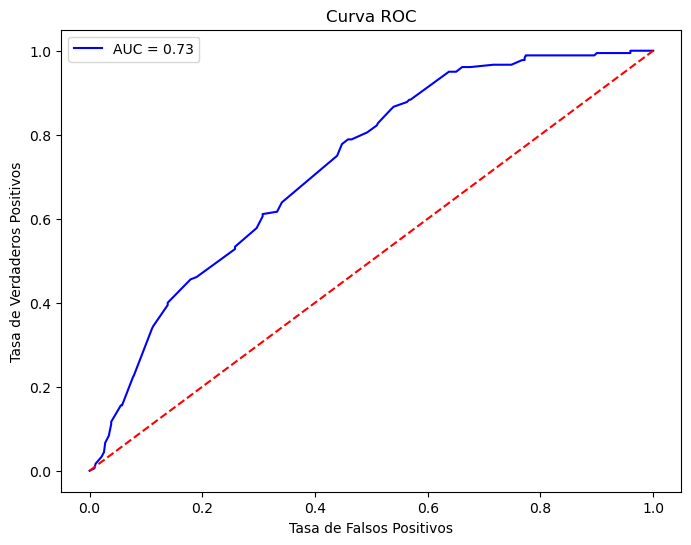

In [95]:
# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}', color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [97]:
# Matriz de confusión
cm = confusion_matrix(data['remainder__Aprueba'], data['prediccion'])
print('\nMatriz de Confusión:')
print(cm)


Matriz de Confusión:
[[451  18]
 [160  20]]


Observamos que de 649 datos que se tienen registrados en la base de estudiantes, el modelo predice correctamente 471 de los registros y proyecta erroneamente 178 casos de estudiantes. Se observa que la mayoría de estos errores pertecen a estudiantes que en la realidad aprobaron pero el modelo indica que no aprueban la materia.

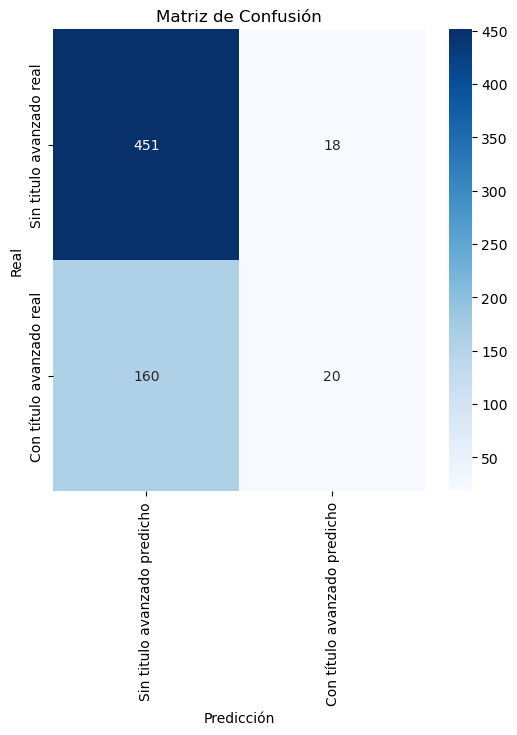

In [98]:
import seaborn as sns
# Matriz de confusión
cm = confusion_matrix(data['remainder__Aprueba'], data['prediccion'])

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Sin titulo avanzado predicho', 'Con título avanzado predicho'], yticklabels=['Sin titulo avanzado real', 'Con título avanzado real'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()